In [2]:
%load_ext autoreload
%autoreload 2

import networkx as nx
from agents import PopulationManager, useful_graph_metrics

In [12]:
print("hello world")

hello world


In [11]:
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display


def plot_graph_step(G, manager, step, pos=None, with_labels=True, node_size=300):
    """
    Plot the graph at a specific step.
    """

    if pos is None:
        pos = nx.spring_layout(G)

    node_order = list(G.nodes())
    colors = manager.get_color_map(step)

    fig, ax = plt.subplots()

    nx.draw_networkx_edges(G, pos, ax=ax)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=node_order,
        node_color=colors,
        node_size=node_size,
        ax=ax
    )

    if with_labels:
        nx.draw_networkx_labels(G, pos, ax=ax)

    ax.set_axis_off()

    display(fig)      # ensures it shows in any cell
    plt.close(fig)    # prevents duplicate rendering

In [9]:
%matplotlib notebook

import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import networkx as nx
import time


def animate_graph_history(
    G,
    manager,
    delay=0.1,
    pos=None,
    with_labels=True,
    node_size=300,
):
    """
    Animate node color changes over the manager history.

    Parameters
    ----------
    G : networkx.Graph
        The graph to draw.
    manager : object
        Must provide:
            - get_color_map(i)
            - get_history()
    delay : float, optional
        Pause time between frames.
    pos : dict, optional
        Node positions. If None, uses nx.spring_layout(G).
    with_labels : bool, optional
        Whether to draw node labels.
    node_size : int, optional
        Size of nodes.
    """
    if pos is None:
        pos = nx.spring_layout(G)

    node_order = list(G.nodes())
    history = manager.get_history()

    fig, ax = plt.subplots()
    prev_colors = manager.get_color_map(0)

    for i in range(len(history)):
        ax.clear()

        # Always draw edges
        nx.draw_networkx_edges(G, pos, ax=ax)

        # Optionally draw labels
        if with_labels:
            nx.draw_networkx_labels(G, pos, ax=ax)

        curr_colors = manager.get_color_map(i)

        if i == 0:
            changed_nodes = node_order
            changed_colors = curr_colors
            unchanged_nodes = []
            unchanged_colors = []
        else:
            changed_nodes = [
                node_order[j]
                for j in range(len(node_order))
                if curr_colors[j] != prev_colors[j]
            ]
            changed_colors = [
                curr_colors[j]
                for j in range(len(node_order))
                if curr_colors[j] != prev_colors[j]
            ]

            unchanged_nodes = [
                node_order[j]
                for j in range(len(node_order))
                if curr_colors[j] == prev_colors[j]
            ]
            unchanged_colors = [
                curr_colors[j]
                for j in range(len(node_order))
                if curr_colors[j] == prev_colors[j]
            ]

        # Draw unchanged nodes first
        if unchanged_nodes:
            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=unchanged_nodes,
                node_color=unchanged_colors,
                node_size=node_size,
                ax=ax,
            )

        # Draw changed nodes on top
        if changed_nodes:
            nx.draw_networkx_nodes(
                G,
                pos,
                nodelist=changed_nodes,
                node_color=changed_colors,
                node_size=node_size,
                ax=ax,
            )

        ax.set_axis_off()
        display(fig)
        clear_output(wait=True)
        time.sleep(delay)

        prev_colors = curr_colors.copy()

    plt.close(fig)

In [51]:
def run_sims(graph, iterations, steps_per_sim=150, random_init=False, **kwargs):
    
    histories = []
    managers = []
    
    for i in range(iterations):
        manager = PopulationManager(graph=graph, init_random=random_init, **kwargs)
        for j in range(steps_per_sim):
            manager.step_all_agents()

        histories.append(manager.get_history_as_counts())
        managers.append(manager)
    return histories, managers


In [58]:
import numpy as np
import matplotlib.pyplot as plt

def plot_seir_iqr(data):
    """
    data format:
        data[simulation][state][time]
        state order = [S, E, I, R]
    """

    data = np.array(data)

    # shape becomes (runs, 4, time)
    q25 = np.percentile(data, 25, axis=0)
    median = np.percentile(data, 50, axis=0)
    q75 = np.percentile(data, 75, axis=0)

    time = np.arange(data.shape[2])

    labels = ["Susceptible", "Exposed", "Infected", "Recovered"]
    colors = ["blue", "orange", "red", "green"]

    fig, ax = plt.subplots()

    for (i, label), color in zip(enumerate(labels), colors):
        ax.plot(time, median[i], label=label, color=color)
        ax.fill_between(time, q25[i], q75[i], alpha=0.25, color=color)

    ax.set_xlabel("Time")
    ax.set_ylabel("Count")
    ax.legend()

    plt.show()

In [15]:
# 2. a circulant graph with 20 vertices where each vertex is attached to four neighbors on either side
graph_2_circulant = nx.circulant_graph(20,[1,2])

# 3. a complete graph with 100 vertices (nx.complete graph(100))
graph_3_complete = nx.complete_graph(100) 

# 4. a 10 × 10 lattice with 100 vertices (nx.grid 2d graph(10,10))
graph_4_lattice = nx.convert_node_labels_to_integers(nx.grid_2d_graph(10,10))

# 5. a scale-free network with 100 vertices (nx.barabasi albert graph(100,???)
graph_5_barabasi_100 = nx.convert_node_labels_to_integers(nx.barabasi_albert_graph(100, 5))
                                   
# 6. a scale-free network with 410 vertices (nx.barabasi albert graph(410,???)
graph_6_barabasi_410 = nx.convert_node_labels_to_integers(nx.barabasi_albert_graph(410, 10))


# 7. infect-dublin network, which has 410 vertices; described and downloadable here:
from read_dublin_graph import _read_graph_from_file
graph_7_dublin = _read_graph_from_file('ia-infect-dublin.mtx')
graph_7_dublin = nx.convert_node_labels_to_integers(graph_7_dublin)


all_graphs = [graph_3_complete,graph_4_lattice, graph_5_barabasi_100, graph_6_barabasi_410,graph_7_dublin]
all_graphs_names = ["Complete Graph", "Lattice Graph", "Barabasi Size 100", "Barabasi Size 410", "Dublin Graph"]


In [32]:
import pandas as pd

In [42]:
def get_managers_averages(managers):
    metrics = [m.get_useful_metrics() for m in managers]
    all_metrics_df = pd.DataFrame(metrics)

    return all_metrics_df.mean().to_dict()

In [43]:
def all_stats(managers, G):
    return useful_graph_metrics(G) | get_managers_averages(managers)

In [29]:

graph_stats = { name: useful_graph_metrics(g)
    for name, g in zip(all_graphs_names, all_graphs)
}


df = pd.DataFrame.from_dict(graph_stats, orient="index")
print(df)

                   maximum degree  average degree  diameter  radius   density
Complete Graph                 99       99.000000         1       1  1.000000
Lattice Graph                   4        3.600000        18      10  0.036364
Barabasi Size 100              35        9.500000         4       3  0.095960
Barabasi Size 410             128       19.512195         3       2  0.047707
Dublin Graph                   50       13.487805         9       5  0.032978


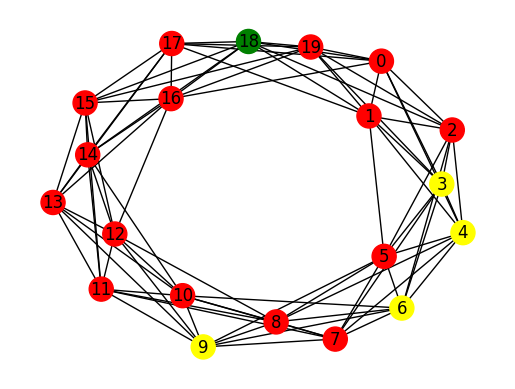

time to peak infection: 11
peak infections: 15
time when steady state reached: 11
number of uninfected individuals at the end of the experiment: 0
maximum degree: 8
average degree: 8.0
diameter: 3
radius: 3
density: 0.42105263157894735


In [30]:
# Graph 1

# Sample usage
G = nx.circulant_graph(20,[1,2,3,4])

num_steps = 12
manager = PopulationManager(graph=G)
for step in range(num_steps):
    manager.step_all_agents()

# animate_graph_history(G, manager)
plot_graph_step(G, manager, 11)


results = manager.get_useful_metrics() | useful_graph_metrics(G)
print('\n'.join(f'{r}: {v}' for r,v in results.items()))

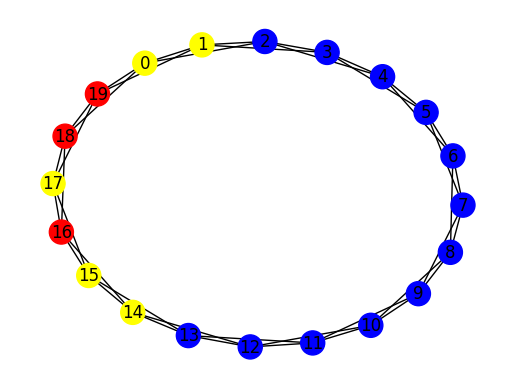

time to peak infection: 8
peak infections: 8
time when steady state reached: 58
number of uninfected individuals at the end of the experiment: 0
maximum degree: 4
average degree: 4.0
diameter: 5
radius: 5
density: 0.21052631578947367


In [27]:
# Graph 2

num_steps = 200
manager_graph_2 = PopulationManager(graph=graph_2_circulant)
for step in range(num_steps):
    manager_graph_2.step_all_agents()
plot_graph_step(graph_2_circulant, manager_graph_2, 5)

results = manager_graph_2.get_useful_metrics() | useful_graph_metrics(graph_2_circulant)
print('\n'.join(f'{r}: {v}' for r,v in results.items()))

## Experiment Conditions 1 


The following are predictions for each of the graphs presented using the default parameters specified. 

### Complete

The contagion will spread very quickly through the graph.
Everyone is connected to everyone, thus significantly increasing the chance that even one infected individaul could infect any of the other individuals directly.
As more people get the virus, the easier it is for a susceptible individual to be exposed. 
Everyone will end up infected and recovered fairly quickly.  

### Lattice

Similar to the complete graph, the contagion will spread relatively quickly throughout the graph because all the nodes have multiple neighbors. 
Because almost every node is well connected, all the nodes will end up infected and recoverd.
It will spread relatively quickly, but there could be pockets that take a little bit longer to get the virus. 
The lattice structure will take longer than the complete structure to propogate everything through the network.   

### Scale Free 100
Preferential attachment model (rich get richer)
New nodes connect to already well connected nodes. 

It will take longer for the virus to spread because there are potentially pockets of nodes that are harder to reach.
Some nodes may have a limited number of connections and the virus has to spread through those nodes for a not well connected
node to get the virus. 
Thus, it would take longer than the lattice or complete graph and there may be 

### Scale Free 410 

The scale free of size 410 will do similarly to scale free size 100.
The predictions made in scale free 100 will just be exacerbated. 
It will take longer with more people (more long paths or the number of hops to get to someone) and 
it is likely there are more non-well connected nodes, thus fewer people (by absolute numbers) 
end up infected at the end. 


### Dublin 

I think the dublin graph will behave similarly to the scale free 410 graph. 
Most nodes will become infected, there may be a few pocket nodes that don't get infected
due to their structure in the graph. Because of the potential for long paths between 
exposed or infected individuals, it will take longer than the scale free 100. 


## Data Collection - Experimental Conditions 1

In [70]:
def run_sim_and_get_info(G):
    data, managers = run_sims(G, 20, steps_per_sim=60, random_init=True, init_E=0.05, init_I=0.05, init_S=.9)

    results = all_stats(managers=managers, G=G)
    print('\n'.join(f'{r}: {v}' for r,v in results.items()))

    plot_seir_iqr(data)
    # animate_graph_history(graph_6_barabasi_410, manager)


maximum degree: 99
average degree: 99.0
diameter: 1
radius: 1
density: 1.0
time to peak infection: 8.9
peak infections: 85.2
time when steady state reached: 43.5
number of uninfected individuals at the end of the experiment: 0.0


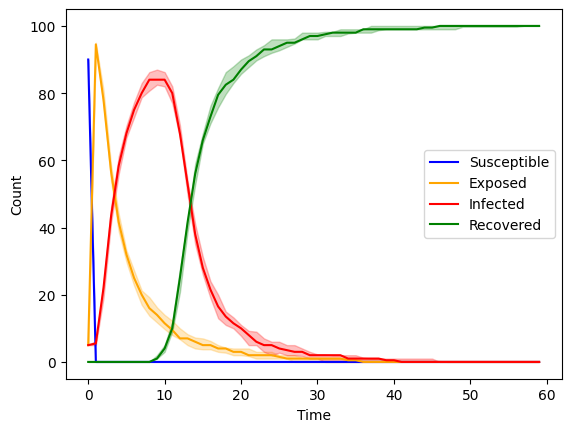

In [72]:
G = graph_3_complete
run_sim_and_get_info(G)


maximum degree: 4
average degree: 3.6
diameter: 18
radius: 10
density: 0.03636363636363636
time to peak infection: 12.65
peak infections: 57.5
time when steady state reached: 49.5
number of uninfected individuals at the end of the experiment: 0.0


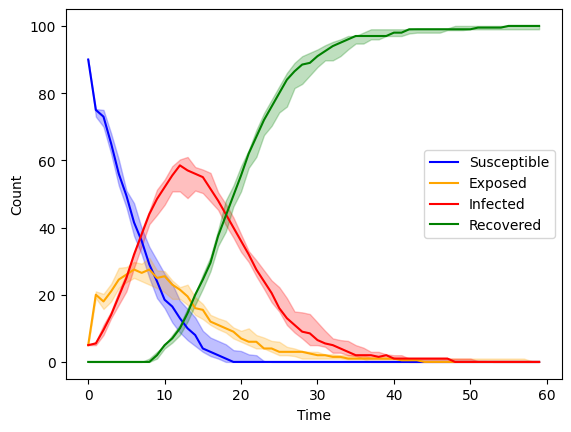

In [73]:
G = graph_4_lattice
run_sim_and_get_info(G)


maximum degree: 35
average degree: 9.5
diameter: 4
radius: 3
density: 0.09595959595959595
time to peak infection: 10.0
peak infections: 80.5
time when steady state reached: 45.7
number of uninfected individuals at the end of the experiment: 0.0


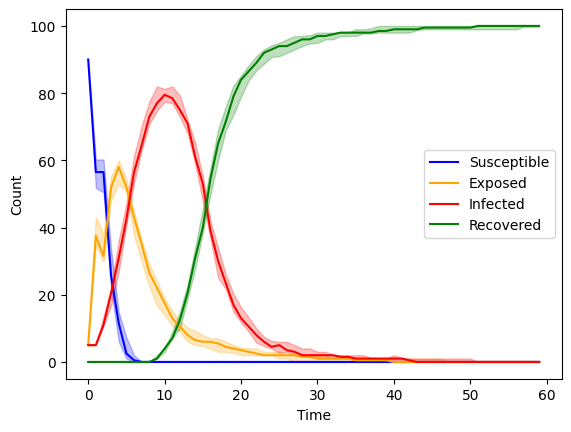

In [74]:
G = graph_5_barabasi_100
run_sim_and_get_info(G)

maximum degree: 128
average degree: 19.51219512195122
diameter: 3
radius: 2
density: 0.047707078537778044
time to peak infection: 9.45
peak infections: 340.3
time when steady state reached: 51.85
number of uninfected individuals at the end of the experiment: 0.0


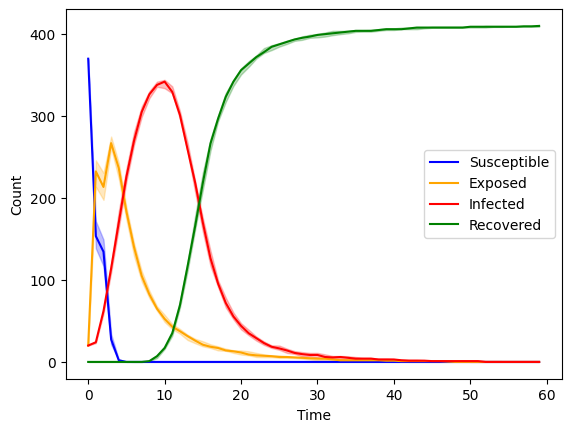

In [75]:
G = graph_6_barabasi_410
run_sim_and_get_info(G)

maximum degree: 50
average degree: 13.487804878048781
diameter: 9
radius: 5
density: 0.032977518039239075
time to peak infection: 10.3
peak infections: 320.75
time when steady state reached: 54.7
number of uninfected individuals at the end of the experiment: 0.0


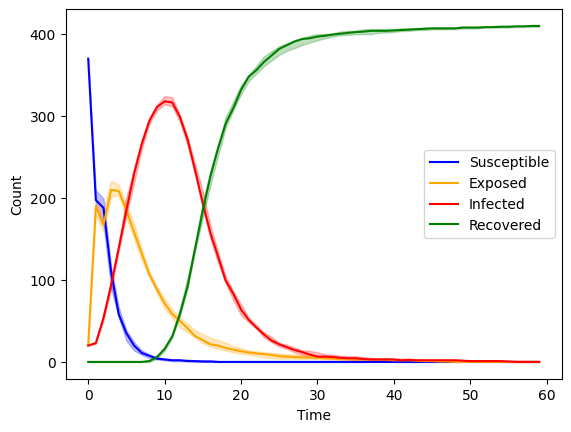

In [76]:
G = graph_7_dublin
run_sim_and_get_info(G)

## Discussion for Experimental Conditions 1

The following are predictions for each of the graphs presented using the default parameters specified. 

### Complete

My prediction that the contagion will spread very quickly through the graph was correct.
The averae time for peak infection was 8.9, a relatively small number.

It took an average of 43.5 to reach the steady state. This surprised me because
it took longer for people to recover than I realized. 

### Lattice

My prediction was largely correctly. My prediction was that that similar to the complete graph, the contagion will spread relatively quickly throughout the lattice graph because all the nodes have multiple neighbors and that the lattice structure will take longer than the complete structure to propogate everything through the network.   

Te average time to peak infections as 12.65, which was larger than aproximately 10 for the fully complete graph. And there were no uninfected individuals at the end of the experiment.

One thing I did not anticipate was the difference in the peak number of infections. For the lattice structre the peak number of infections is 57.5 rather than 85.2 for the complete graph. This makes sense because it is taking longer for certain people to get infected. It is impossible for everyone to get infected at once, unlike the fully connected graph. 


### Scale Free 100

My prediction was that it will take longer for the virus to spread because there are potentially pockets of nodes that are harder to reach.

My prediciton was incorrect. The time to peak infections was 10 -- comparable to the completely connected graph, even though the radius and diameter are larger. 
I think this may be because it becomes very easy for multiple high connected nodes to be infected and then they high connected nodes are able to easily infect everyone else.
So in a sense, the scale free graph allows for the structure to work almost like a completely connected graph -- most everyone is connected to someone else influential. 

### Scale Free 410 

My prediction was that the scale free of size 410 will do similarly to scale free size 100. It will take longer with more people and fewer people end up infected at the end. 

I was wrong on both accounts. Time to peak infections was around 10 -- similar to size 100 and the completely connected graph. I think it took a similar amount of times becase of the particular nature of the graph structure as described in the previous graph. 
Everyone still ended up infected. There are less protective type factiors in this network. Nodes are more connected than I realized making it very difficult to have a completely isolated node, or a node with few connections that would get them infected. 

### Dublin 
I predicted that the dublin graph will behave similarly to the scale free 410 graph. 

I was correct that it behaved similarly, but I was incorrect about the amount of time and that there would be non-infected individuals. It took about 10 steps to reach peak infection and everyone ended up infected. 
Again, due to the graph structure, it influences how it spreads and to who it spreads.
I think because there are enough high degree, well connected nodes, it is possible to get to infecting everyone fairly quickly.  

                   maximum degree  average degree  diameter  radius   density
Complete Graph                 99       99.000000         1       1  1.000000
Lattice Graph                   4        3.600000        18      10  0.036364
Barabasi Size 100              33        9.500000         4       3  0.095960
Barabasi Size 410              92       19.512195         3       2  0.047707
Dublin Graph                   50       13.487805         9       5  0.032978


## Experimental Conditions 2

The following are precitions for each of the scenarios with the adjusted parameters. 


